# TRIM package
<img src="../trim_logo.png" width=200 height=200>

## Table of Contents
* [1. Computation of the measures for the set of triplets](#section_1)
    * [1.1. Longer range](#section_1_1)
    * [1.2. Short range](#section_1_2)
* [2. Comparison of different measures](#section_2)
* [3. Triadic interactions in gene expression](#section_3)
    * [3.1. Non triadic](#section_3_1)
    * [3.2. Triadic monotonic](#section_3_2)
    * [3.3. Triadic non-monotonic](#section_3_3)
* [4. Distribution for an edge](#section_4)
* [5. Visualisation of triadic network](#section_5)

In [1]:
from trim.analysis import decision_tree, visualisation_conditioned
from trim.analysis import visualisation_conditioned_val
import matplotlib.pyplot as plt
import matplotlib as mpl
import trim.infocore as ifc
import networkx as nx
import seaborn as sns
import pandas as pd
import scipy as sp
import numpy as np
import glob
import os

In [2]:
# The following notebook assumes that the set of triplets has been already defined.
save_folder = "../output"
try : 
    os.mkdir(save_folder)
except OSError : 
    pass

gene_expression = pd.read_csv('../data/reduce_gene_expression.tsv', sep = '\t', index_col=0)
triadic_set = pd.read_csv('../data/final.tsv', sep = '\t')

In [3]:
ppi = pd.read_csv('../data/reduce_ppi.tsv', sep = '\t')
graph_ppi = nx.from_pandas_edgelist(ppi, source = '0', target = '1')
Gcc = sorted(nx.connected_components(graph_ppi), key=len, reverse=True)
G0 = graph_ppi.subgraph(Gcc[0])
#print(nx.diameter(G0)) -> 4
list_node = list(graph_ppi.nodes())
print('PPI')
print('number of edges: ', len(graph_ppi.edges()))
print('number of nodes: ', len(graph_ppi.nodes()))

PPI
number of edges:  42511
number of nodes:  639


In [4]:
gene_expression.head()

,TCGA-AB-2876-03A,TCGA-AB-2952-03B,TCGA-AB-2915-03A,TCGA-AB-2929-03A,TCGA-AB-2938-03A,TCGA-AB-2849-03A,TCGA-AB-2877-03A,TCGA-AB-2986-03A,TCGA-AB-2971-03A,TCGA-AB-2955-03A,...,TCGA-AB-2979-03B,TCGA-AB-2928-03A,TCGA-AB-2825-03A,TCGA-AB-2873-03A,TCGA-AB-2920-03B,TCGA-AB-2862-03A,TCGA-AB-2939-03A,TCGA-AB-2927-03A,TCGA-AB-2897-03A,TCGA-AB-2990-03B
NFYA,11.718391,11.015797,11.563136,11.625043,11.974561,12.686500,11.596328,11.365092,11.495804,11.950957,...,11.555033,11.603535,10.882933,11.322924,10.954068,11.943764,12.034599,11.821913,12.115518,11.359962
ARX,0.627285,0.892046,0.713059,0.016001,1.516500,0.004867,1.140249,2.883369,1.604872,0.018067,...,1.765541,0.039797,2.315755,1.261999,0.598371,0.665085,0.032957,2.014373,2.159402,1.449488
MEOX1,1.952423,3.638907,1.328262,2.298384,2.592035,1.911397,1.585473,1.220719,3.033813,0.528005,...,3.266452,0.039797,2.807471,3.666987,0.027852,1.292156,0.032957,2.914965,0.543268,2.258207
SOX8,1.205366,4.168124,2.541573,0.016001,2.305108,4.896737,4.987690,1.804591,3.033813,1.678632,...,3.266452,5.820970,1.540766,2.320720,4.045007,4.420094,0.664942,4.005753,1.133044,2.779263
ZFX,12.462581,11.646989,12.218397,13.431845,11.388452,11.751944,12.152364,11.774591,12.277198,12.861790,...,11.691176,12.595078,12.058522,11.998123,11.030582,11.555033,11.427934,11.847961,11.612413,11.393401


## 1. Computation of the measures for the set of triplets  <a class="anchor" id="section_1"></a> 

### 1.1. Longer range  <a class="anchor" id="section_1_1"></a> 

In [5]:
# long_range = pd.read_csv('data/long_range.txt', sep = '\t')

In [6]:
# print('P<0.1:', len(long_range[long_range['P']<0.1])/len(long_range)*100)
# print('P<0.05:', len(long_range[long_range['P']<0.05])/len(long_range)*100)
# print('P<0.01:', len(long_range[long_range['P']<0.01])/len(long_range)*100)
# print('P<0.005:', len(long_range[long_range['P']<0.005])/len(long_range)*100)
# print('P<0.001:', len(long_range[long_range['P']<0.001])/len(long_range)*100)
# print('P<0.0002:', len(long_range[long_range['P']==0.0002])/len(long_range)*100) # limit P = 1/5000 = 0.0002

In [7]:
# top_long_range = long_range[long_range['P']<0.001].sort_values(by = 'Theta', ascending = False)
# unique_long_range = np.unique(top_long_range[['node1','node2']].values.astype(str), axis=0)
# print('unique long range edge:', len(unique_long_range))

### 1.2. Short range  <a class="anchor" id="section_1_1"></a> 

In [8]:
# short_range = pd.read_csv('data/short_range.txt', sep = '\t')

In [9]:
# print('P<0.1:', len(short_range[short_range['P']<0.1])/len(short_range)*100)
# print('P<0.05:', len(short_range[short_range['P']<0.05])/len(short_range)*100)
# print('P<0.01:', len(short_range[short_range['P']<0.01])/len(short_range)*100)
# print('P<0.005:', len(short_range[short_range['P']<0.005])/len(short_range)*100)
# print('P<0.001:', len(short_range[short_range['P']<0.001])/len(short_range)*100)
# print('P<0.0002:', len(short_range[short_range['P']==0.0002])/len(short_range)*100) # limit P = 1/5000 = 0.0002

In [10]:
# top_short_range = short_range[short_range['P']<0.001].sort_values(by = 'Theta', ascending = False)
# unique_short_range = np.unique(top_short_range[['node1','node2']].values.astype(str), axis=0)
# print('unique short range edge:', len(unique_short_range))

In [11]:
# def number_different_nodes(data):
#     out = len(np.unique(data['reg'].values))
#     return out

# def number_different_edges(data):
#     edges_list = list()
#     for k in range(len(data)):
#         temp = (data['node1'].iloc[k], data['node2'].iloc[k])
#         edges_list.append(temp)
#     out = len(list(dict.fromkeys(edges_list)))
#     return out
   
# print('Short range')
# print('number different nodes: ', number_different_nodes(short_range))
# print('number different edges: ', number_different_edges(short_range)) 

# print('Long range')
# print('number different nodes: ', number_different_nodes(long_range))
# print('number different edges: ', number_different_edges(long_range)) 

## 2. Comparison of different measures  <a class="anchor" id="section_2"></a> 

In [12]:
def vis_measures(data, title = None):
    Theta = data['Theta'].astype(float)
    Theta_T = data['Theta_T'].astype(float)
    Theta_Tn = data['Theta_Tn'].astype(float)
    density = sp.stats.gaussian_kde(Theta)
    n, x, _ = plt.hist(Theta, bins = np.linspace(0, np.max(Theta), 50), histtype=u'step', density=True)  
    plt.plot(x, density(x), label = r'$\mathregular{\Theta_\Sigma}$')

    density = sp.stats.gaussian_kde(Theta_T)
    n, x, _ = plt.hist(Theta_T, bins = np.linspace(0, np.max(Theta_T), 50), histtype=u'step', density=True)  
    plt.plot(x, density(x), label = r'$\mathregular{\Theta_T}$')

    density = sp.stats.gaussian_kde(Theta_Tn)
    n, x, _ = plt.hist(Theta_Tn, bins = np.linspace(0, np.max(Theta_Tn), 50), histtype=u'step', density=True)  
    plt.plot(x, density(x), label = r'$\mathregular{\Theta_{Tn}}$')

    plt.xlabel(r'$\mathregular{\Theta}$', fontsize=12)
    plt.ylabel('Probability density function', fontsize=12)
    plt.yscale('log')
    if title != None:
        plt.title(title)
    plt.legend()
    plt.savefig(save_folder + '/' + 'zscore_m.png', format = 'png', dpi = 600)
    plt.show()

In [13]:
def vis_measures2(data1, data2, title = None):
    Theta = data1['Theta'].astype(float)
    Theta_T = data1['Theta_T'].astype(float)
    Theta_Tn = data1['Theta_Tn'].astype(float)
    density = sp.stats.gaussian_kde(Theta)
    n, x, _ = plt.hist(Theta, bins = np.linspace(0, np.max(Theta), 50), histtype=u'step', density=True, alpha = 0)  
    plt.plot(x, density(x), label = r'$\mathregular{\Sigma}$', color = 'lightblue')

    density = sp.stats.gaussian_kde(Theta_T)
    n, x, _ = plt.hist(Theta_T, bins = np.linspace(0, np.max(Theta_T), 50), histtype=u'step', density=True, alpha = 0)
    plt.plot(x, density(x), label = r'$\mathregular{T}$', color = 'royalblue')

    density = sp.stats.gaussian_kde(Theta_Tn)
    n, x, _ = plt.hist(Theta_Tn, bins = np.linspace(0, np.max(Theta_Tn), 50), histtype=u'step', density=True, alpha = 0) 
    plt.plot(x, density(x), label = r'$\mathregular{Tn}$', color = 'navy')
    plt.legend()
    
    Theta = data2['Theta'].astype(float)
    Theta_T = data2['Theta_T'].astype(float)
    Theta_Tn = data2['Theta_Tn'].astype(float)
    density = sp.stats.gaussian_kde(Theta)
    n, x, _ = plt.hist(Theta, bins = np.linspace(0, np.max(Theta), 50), histtype=u'step', density=True, alpha = 0)
    plt.plot(x, density(x), label = r'$\mathregular{\Sigma}$', color = 'lightcoral')

    density = sp.stats.gaussian_kde(Theta_T)
    n, x, _ = plt.hist(Theta_T, bins = np.linspace(0, np.max(Theta_T), 50), histtype=u'step', density=True, alpha = 0)  
    plt.plot(x, density(x), label = r'$\mathregular{T}$', color = 'indianred')

    density = sp.stats.gaussian_kde(Theta_Tn)
    n, x, _ = plt.hist(Theta_Tn, bins = np.linspace(0, np.max(Theta_Tn), 50), histtype=u'step', density=True, alpha = 0)
    plt.plot(x, density(x), label = r'$\mathregular{Tn}$', color = 'firebrick')

    plt.xlabel(r'$\mathregular{\Theta}$', fontsize=12)
    plt.ylabel('Probability density function', fontsize=12)
    plt.yscale('log')
    if title != None:
        plt.title(r'$\mathregular{i}$'.replace('i', title))
    lines = plt.gca().get_lines()
    legend1 = plt.legend([lines[i] for i in [0,1,2]],[lines[i].get_label() for i in [0,1,2]], loc=3, title = "short range")
    legend2 = plt.legend([lines[i] for i in [3,4,5]],[r'$\mathregular{\Sigma}$',r'$\mathregular{T}$', r'$\mathregular{Tn}$'], loc=8, title = "long range")
    plt.gca().add_artist(legend1)
    plt.savefig(save_folder + '/' + 'zscore_m2.png', format = 'png', dpi = 600)
    plt.show()

In [14]:
def vis_corr_measures(data1, data2, label = None):
    if len(data1) != len(data2):
        print('data1 and data2 do not have the same dimension!')
        
    if label == None:   
        data = pd.DataFrame({'type': np.repeat([0, 1], len(data1))})
        data['Theta'] = pd.concat([data1['Theta'].astype(float), data2['Theta'].astype(float)]).reset_index(drop=True)
        data['Theta_T'] = pd.concat([data1['Theta_T'].astype(float), data2['Theta_T'].astype(float)]).reset_index(drop=True)
        data['Theta_Tn'] = pd.concat([data1['Theta_Tn'].astype(float), data2['Theta_Tn'].astype(float)]).reset_index(drop=True)

        g = sns.jointplot(data=data, x='Theta', y='Theta_T', hue='type', hue_order=[0,1],
                          palette=['dodgerblue', 'crimson'])
        sns.move_legend(g.ax_joint, title='', loc='best', markerscale=1)
        plt.xlabel(r'$\mathregular{\Theta_\Sigma}$ score', fontsize=12)
        plt.ylabel(r'$\mathregular{\Theta_T}$ score', fontsize=12)
        plt.legend(fontsize='14')
        plt.savefig(save_folder + '/' + 'zscore1.png', format = 'png', dpi = 600)
        plt.show()

        g = sns.jointplot(data=data, x='Theta', y='Theta_Tn', hue='type', hue_order=[0,1],
                          palette=['dodgerblue', 'crimson'])
        sns.move_legend(g.ax_joint, title='', loc='best', markerscale=1)
        plt.xlabel(r'$\mathregular{\Theta_\Sigma}$ score', fontsize=12)
        plt.ylabel(r'$\mathregular{\Theta_{Tn}}$ score', fontsize=12)
        plt.legend(fontsize='14')
        plt.savefig(save_folder + '/' + 'zscore2.png', format = 'png', dpi = 600)
        plt.show()
    else: 
        data = pd.DataFrame({'type': np.repeat([label[0], label[1]], len(data1))})
        data['Theta'] = pd.concat([data1['Theta'].astype(float), data2['Theta'].astype(float)]).reset_index(drop=True)
        data['Theta_T'] = pd.concat([data1['Theta_T'].astype(float), data2['Theta_T'].astype(float)]).reset_index(drop=True)
        data['Theta_Tn'] = pd.concat([data1['Theta_Tn'].astype(float), data2['Theta_Tn'].astype(float)]).reset_index(drop=True)

        g = sns.jointplot(data=data, x='Theta', y='Theta_T', hue='type', hue_order=[label[0], label[1]],
                          palette=['dodgerblue', 'crimson'])
        sns.move_legend(g.ax_joint, title='', loc='best', markerscale=1)
        plt.xlabel(r'$\mathregular{\Theta_\Sigma}$ score', fontsize=12)
        plt.ylabel(r'$\mathregular{\Theta_T}$ score', fontsize=12)
        plt.legend(fontsize='14')
        plt.savefig(save_folder + '/' + 'zscore1.png', format = 'png', dpi = 600)
        plt.show()

        g = sns.jointplot(data=data, x='Theta', y='Theta_Tn', hue='type', hue_order=[label[0], label[1]],
                          palette=['dodgerblue', 'crimson'])
        sns.move_legend(g.ax_joint, title='', loc='best', markerscale=1)
        plt.xlabel(r'$\mathregular{\Theta_\Sigma}$ score', fontsize=12)
        plt.ylabel(r'$\mathregular{\Theta_{Tn}}$ score', fontsize=12)
        plt.legend(fontsize='14')
        plt.savefig(save_folder + '/' + 'zscore2.png', format = 'png', dpi = 600)
        plt.show()

In [15]:
def vis3d_corr_measures(data1, data2, title = None):
    data = pd.concat([data1, data2])
    x = data['Theta'].astype(float)
    y = data['Theta_T'].astype(float)
    z = data['Theta_Tn'].astype(float)
    color = z/np.sum(z)
    
    fig = plt.figure(figsize=(8,8))
    ax = fig.add_subplot(111, projection='3d', azim = -15, elev = 65)
    fig.add_axes(ax)
    sc = ax.scatter(x, y, z, s=2, c=color, marker='o', cmap = 'turbo', alpha=0.7)
    ax.set_xlabel(r'$\mathregular{\Theta_\Sigma}$ score', fontsize=10, color='black')
    ax.set_ylabel(r'$\mathregular{\Theta_T}$ score', fontsize=10, color='black')
    ax.set_zlabel(r'$\mathregular{\Theta_{Tn}}$ score', fontsize=10, color='black')
    ax.set_box_aspect(None, zoom=0.8)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.tick_params(axis='both', which='minor', labelsize=8)
    if title != None:
        plt.title(title)
    # legend
    plt.savefig(save_folder + '/' + 'zscore3.png', format = 'png', dpi = 600)
    plt.show()

In [16]:
def MI_MIC(data1, data2, key = 'Sigma', display = None, label = None):
    plt.figure(figsize=(12,5))
    if key in {'P', 'P_T', 'P_Tn'}:
        plt.subplot(121)
        x = data1['MIC'].astype(float)
        y = data1['MI'].astype(float)
        z = np.log(1/data1[key].astype(float))
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'Blues')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 2:
            plt.xlim(0, max(data2['MIC'].astype(float))+ 0.1*max(data2['MIC'].astype(float)))
            plt.ylim(0, max(data2['MI'].astype(float))+ 0.1*max(data2['MI'].astype(float)))
        plt.xlabel('MI(XY|Z)', fontsize=10, color='black')
        plt.ylabel('MI(XY)', fontsize=10,color='black')
        if label != None:
            plt.title(label[0])
        cbar = plt.colorbar()
        cbar.ax.set_xlabel(r'$\mathregular{\ln{(1/i)}}$'.replace('i', key), rotation=0, fontsize=10)
        plt.subplot(122)
        x = data2['MIC'].astype(float)
        y = data2['MI'].astype(float)
        z = np.log(1/data2[key].astype(float))
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'Reds')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 1:
            plt.xlim(0, max(data1['MIC'].astype(float)) + 0.1*max(data1['MIC'].astype(float)))
            plt.ylim(0, max(data1['MI'].astype(float)) + 0.1*max(data1['MI'].astype(float)))
        plt.xlabel('MI(XY|Z)', fontsize=10, color='black')
        plt.ylabel('MI(XY)', fontsize=10,color='black')
        if label != None:
            plt.title(label[1])
        cbar = plt.colorbar()
        cbar.ax.set_xlabel(r'$\mathregular{\ln{(1/i)}}$'.replace('i', key), rotation=0, fontsize=10)
        plt.savefig(save_folder + '/' + 'MI.png', format = 'png', dpi = 600)
        plt.show()
    else:
        plt.subplot(121)
        x = data1['MIC'].astype(float)
        y = data1['MI'].astype(float)
        z = data1[key].astype(float)
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'Blues')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 2:
            plt.xlim(0, max(data2['MIC'].astype(float))+ 0.1*max(data2['MIC'].astype(float)))
            plt.ylim(0, max(data2['MI'].astype(float))+ 0.1*max(data2['MI'].astype(float)))
        plt.xlabel('MI(XY|Z)', fontsize=10, color='black')
        plt.ylabel('MI(XY)', fontsize=10,color='black')
        if label != None:
            plt.title(label[0])
        cbar = plt.colorbar()
        cbar.ax.set_xlabel(r'$\mathregular{\i}$'.replace('i', key), rotation=0, fontsize=10)
        plt.subplot(122)
        x = data2['MIC'].astype(float)
        y = data2['MI'].astype(float)
        z = data2[key].astype(float)
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'Reds')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 1:
            plt.xlim(0, max(data1['MIC'].astype(float)) + 0.1*max(data1['MIC'].astype(float)))
            plt.ylim(0, max(data1['MI'].astype(float)) + 0.1*max(data1['MI'].astype(float)))
        plt.xlabel('MI(XY|Z)', fontsize=10, color='black')
        plt.ylabel('MI(XY)', fontsize=10,color='black')
        if label != None:
            plt.title(label[1])
        cbar = plt.colorbar()
        cbar.ax.set_xlabel(r'$\mathregular{\i}$'.replace('i', key), rotation=0, fontsize=10)
        plt.savefig(save_folder + '/' + 'MI.png', format = 'png', dpi = 600)
        plt.show()

In [17]:
def MI_MIC_merge(data1, data2, key = 'Sigma', display = None, label = None):
    data = pd.concat([data1, data2]).reset_index(drop=True)
    plt.figure(figsize=(9,7))
    if key in {'P', 'P_T', 'P_Tn'}:
        x = data['MIC'].astype(float)
        y = data['MI'].astype(float)
        z = np.log(1/data[key].astype(float))
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'turbo')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 1:
            plt.xlim(0, max(data1['MIC'].astype(float)) + 0.1*max(data1['MIC'].astype(float)))
            plt.ylim(0, max(data1['MI'].astype(float)) + 0.1*max(data1['MI'].astype(float)))
        if display == 2:
            plt.xlim(0, max(data2['MIC'].astype(float))+ 0.1*max(data2['MIC'].astype(float)))
            plt.ylim(0, max(data2['MI'].astype(float))+ 0.1*max(data2['MI'].astype(float)))
        plt.xlabel('CMI', fontsize=10, color='black')
        plt.ylabel('MI', fontsize=10,color='black')
#        plt.plot([0,max(np.max(np.array(x)),np.max(np.array(y)))], [0,max(np.max(np.array(x)),np.max(np.array(y)))], '--k')
        if label != None:
            plt.title(label[0])
        cbar = plt.colorbar()
        cbar.ax.set_xlabel(r'$\mathregular{\ln{(1/i)}}$'.replace('i', key), rotation=0, fontsize=10)
        plt.savefig(save_folder + '/' + 'MI_merge.png', format = 'png', dpi = 600)
        plt.show()
    else:
        x = data['MIC'].astype(float)
        y = data['MI'].astype(float)
        z = data[key].astype(float)
        plt.scatter(x, y, c=z, s = 5, alpha=0.8, cmap = 'turbo')
        plt.xlim(xmin=0)
        plt.ylim(ymin=0)
        if display == 1:
            plt.xlim(0, max(data1['MIC'].astype(float)) + 0.1*max(data1['MIC'].astype(float)))
            plt.ylim(0, max(data1['MI'].astype(float)) + 0.1*max(data1['MI'].astype(float)))
        if display == 2:
            plt.xlim(0, max(data2['MIC'].astype(float))+ 0.1*max(data2['MIC'].astype(float)))
            plt.ylim(0, max(data2['MI'].astype(float))+ 0.1*max(data2['MI'].astype(float)))
        plt.xlabel('CMI', fontsize=10, color='black')
        plt.ylabel('MI', fontsize=10,color='black')
#        plt.plot([0,max(np.max(np.array(x)),np.max(np.array(y)))], [0,max(np.max(np.array(x)),np.max(np.array(y)))], '--k')
        if label != None:
            plt.title(label[0])
        cbar = plt.colorbar()
        if key == 'Sigma':
            cbar.ax.set_xlabel(r'$\mathregular{\i}$'.replace('i', key), rotation=0, fontsize=10)
        else:
            cbar.ax.set_xlabel(r'$\mathregular{i}$'.replace('i', key), rotation=0, fontsize=10)
        plt.savefig(save_folder + '/' + 'MI_merge.png', format = 'png', dpi = 600)
        plt.show()

In [18]:
# vis_measures(short_range, title = 'Short range')
# vis_measures(long_range, title = 'Longer range')

In [19]:
# vis_measures2(short_range, long_range, title = '\Theta')

In [20]:
# vis_corr_measures(short_range, long_range, ('short range', 'longer range'))

In [21]:
# vis3d_corr_measures(short_range, long_range, 'short and longer range')

In [22]:
# MI_MIC(short_range, long_range, 'Sigma', display = 1, label = ('short range', 'long range'))

In [23]:
# MI_MIC(short_range, long_range, 'Theta', display = 1, label = ('short range', 'long range'))

In [24]:
# MI_MIC(short_range, long_range, 'P', display = 1, label = ('short range', 'long range'))

In [25]:
# MI_MIC_merge(short_range, long_range, key = 'Sigma', display = 1, label = None)

## 3. Triadic interactions in gene expression  <a class="anchor" id="section_3"></a> 

### 3.1. Non triadic  <a class="anchor" id="section_3_1"></a> 

Sigma, T, Tn 0.02966847112652267 0.07597343234399911 0.07597343234399911
Sigma_mean_null 0.04830307899480079
T_mean_null 0.12253998602248711
Tn_mean_null 0.11615756554504893
P 0.705 P_T 0.698 P_Tn 0.677
Theta 0.6062422112926195 Theta_T 0.5864223593623459 Theta_Tn 0.5287730281246846
4 1.7
4 1.7
0.1722453805665704 0.2197796146024485 0.705


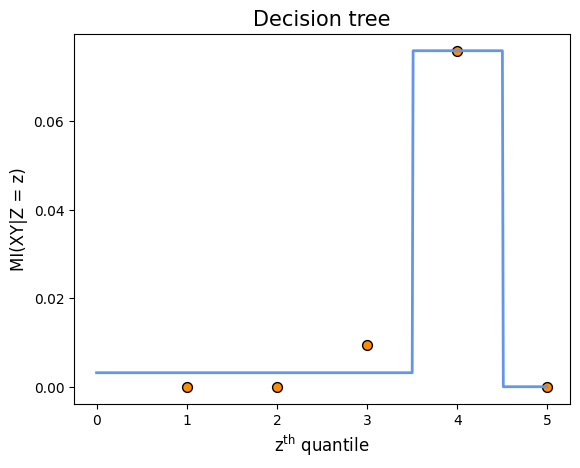

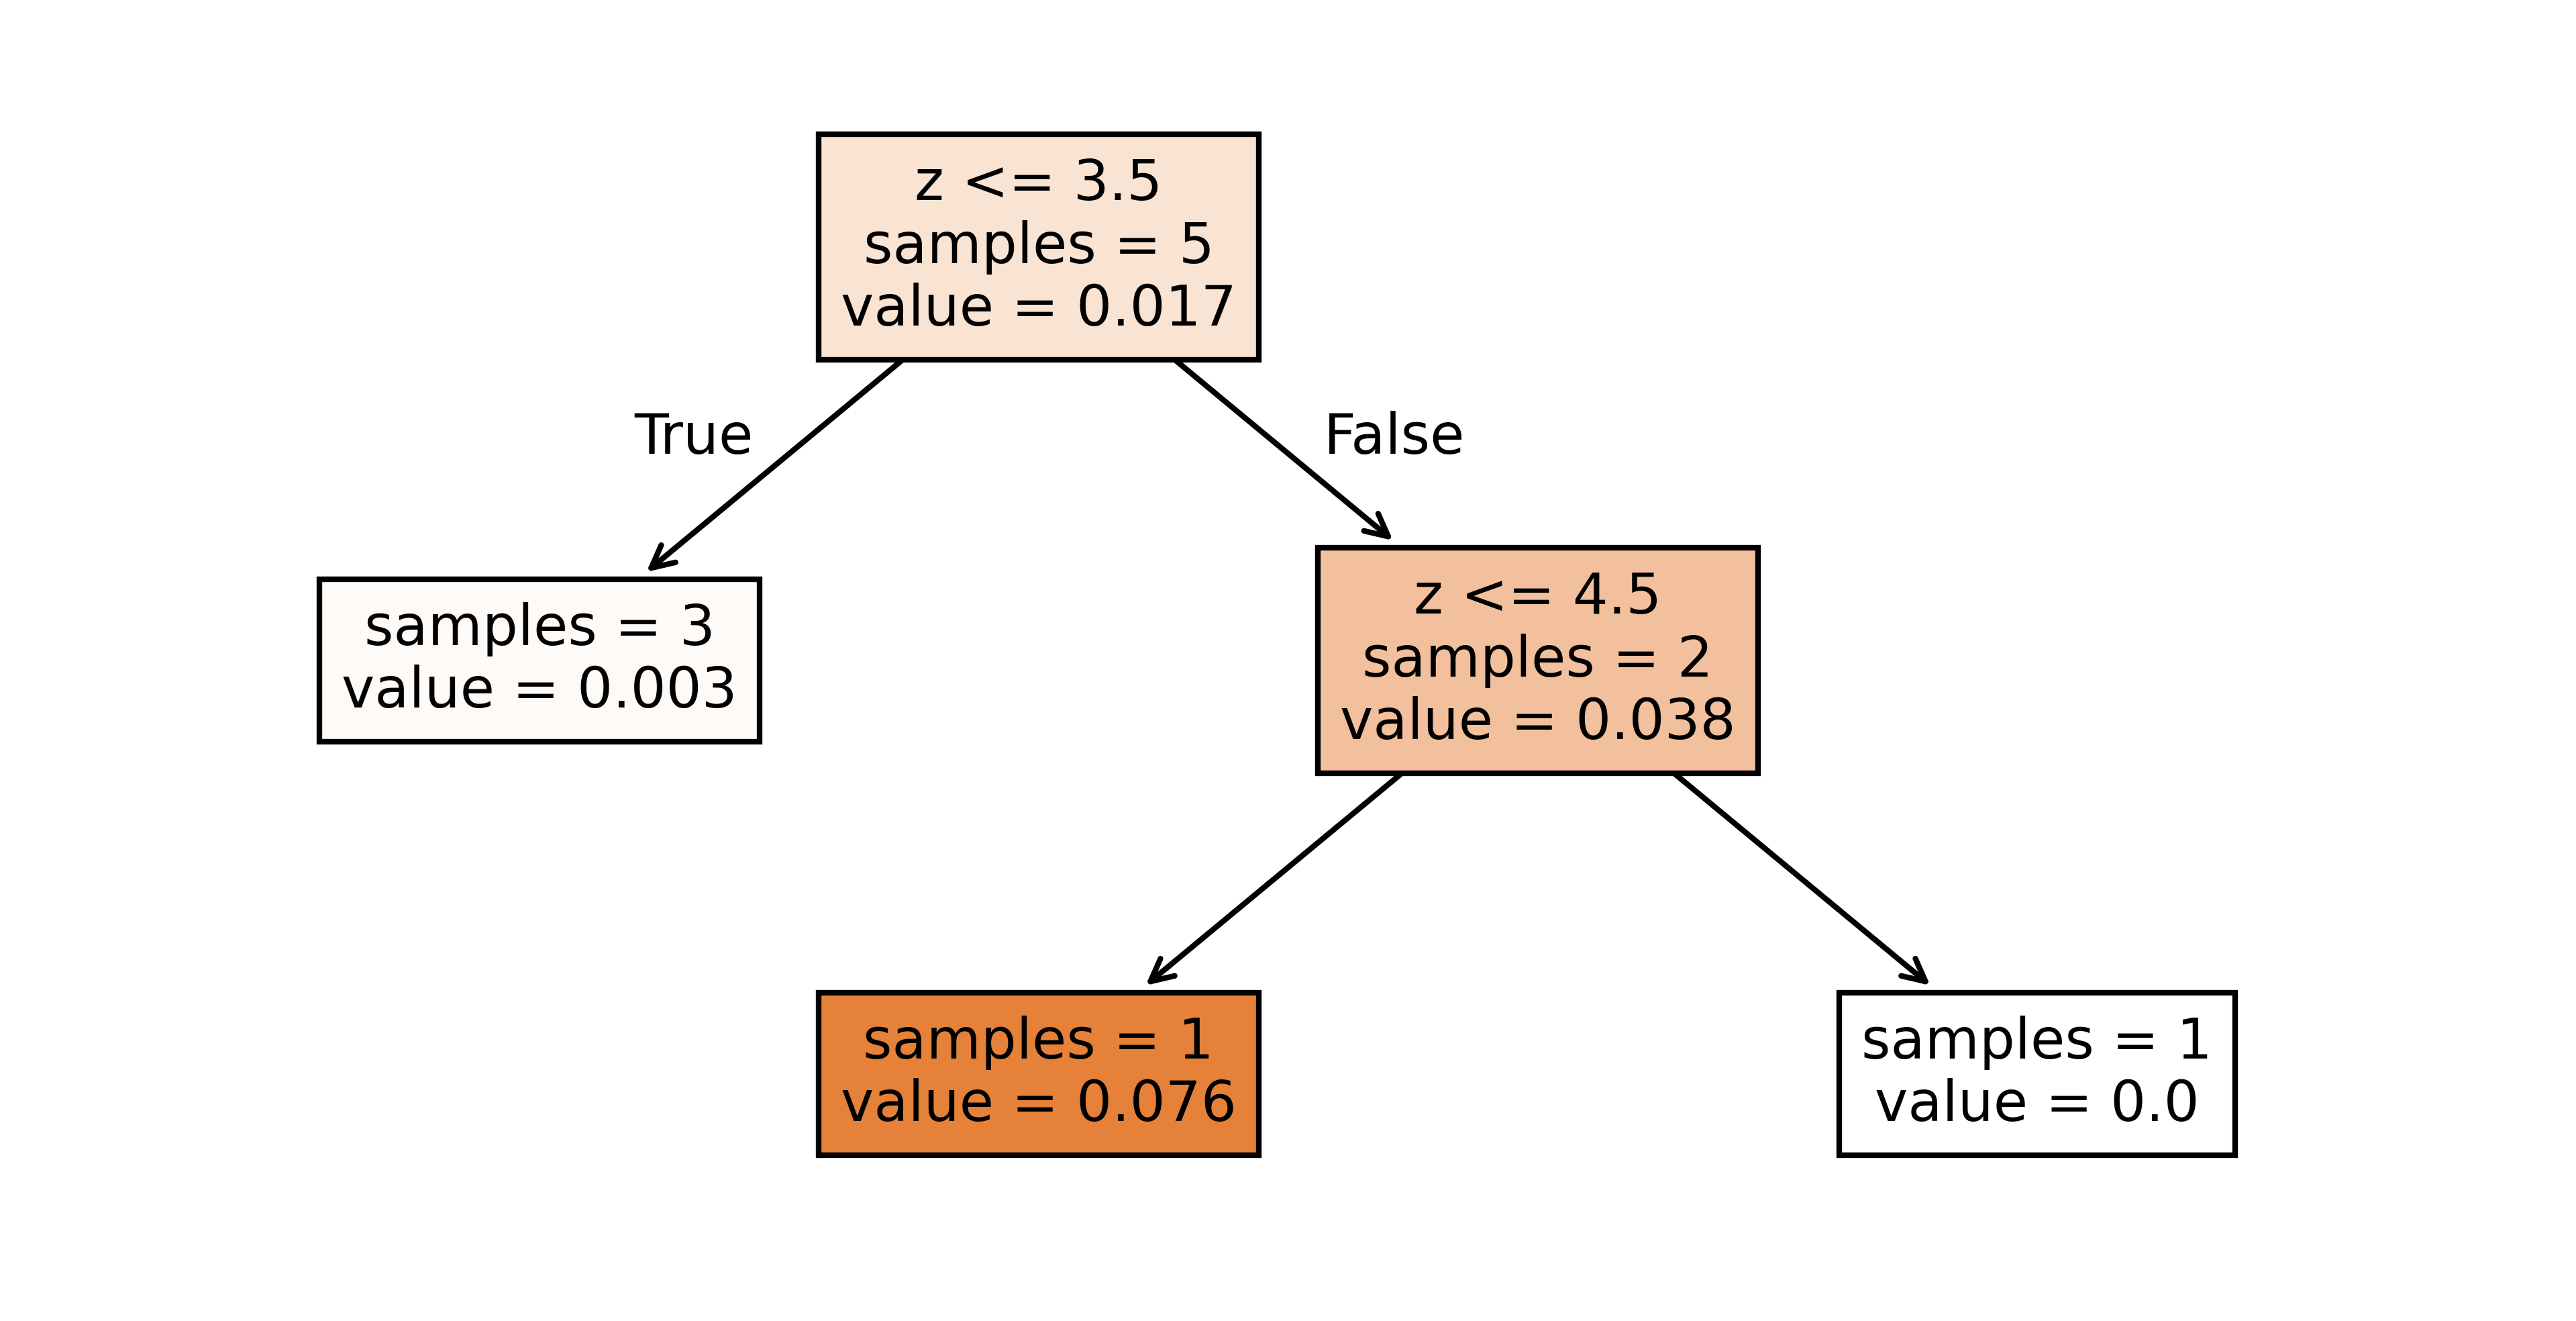

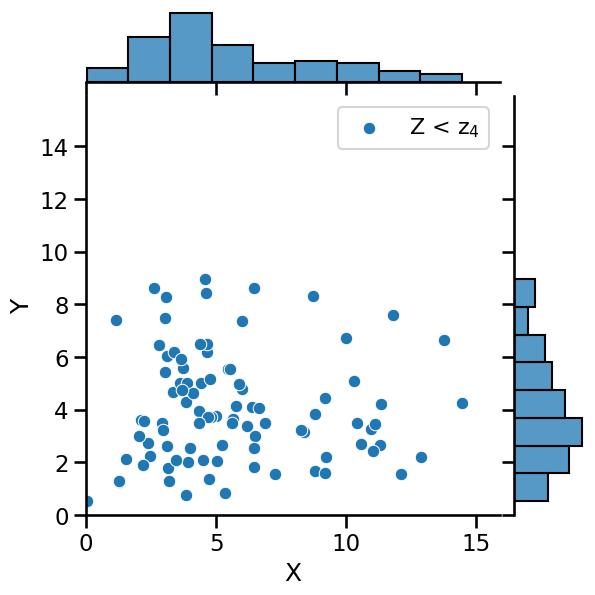

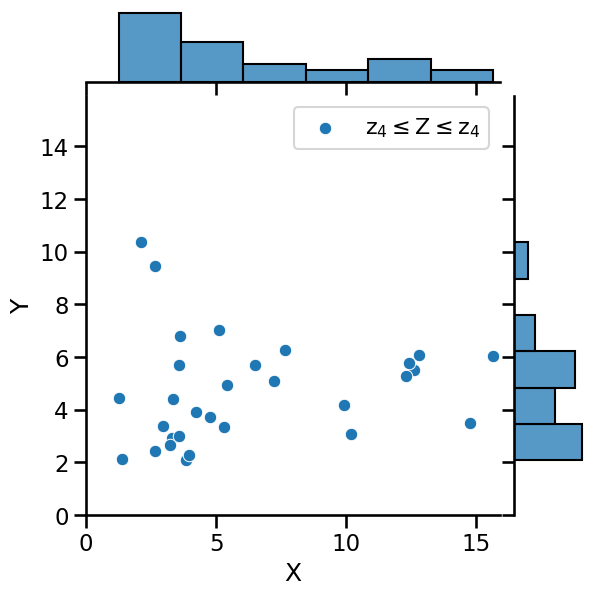

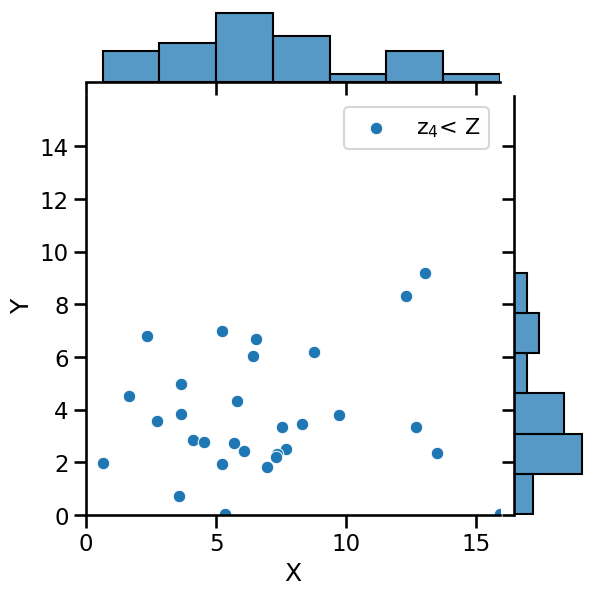

<Figure size 1200x600 with 0 Axes>

In [26]:
name_X = 'IRF6'
name_Y = 'NKX3-1'
name_Z = 'SRY'
X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 1000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True)
I = [0,1,2]
visualisation_conditioned_val(timeseries, I, num, tlen, cond = [th1,th2])
print(np.sqrt(Sigma), np.sqrt(np.mean(Sigma_null_list)), P)

### 3.2. Triadic monotonic  <a class="anchor" id="section_3_2"></a>

Sigma, T, Tn 0.43762528410580764 1.196219491386406 0.7216648365182827
Sigma_mean_null 0.1366527907794674
T_mean_null 0.37741437962292845
Tn_mean_null 0.3245202236073753
P 0.001 P_T 0.001 P_Tn 0.006
Theta 6.018145012702476 Theta_T 5.828520044449444 Theta_Tn 2.8400406341185307
4 12.8
4 12.8
0.6615325268690933 0.369665782538048 0.001


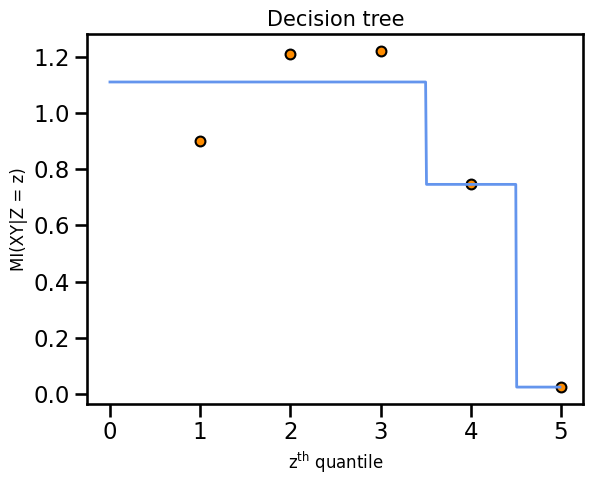

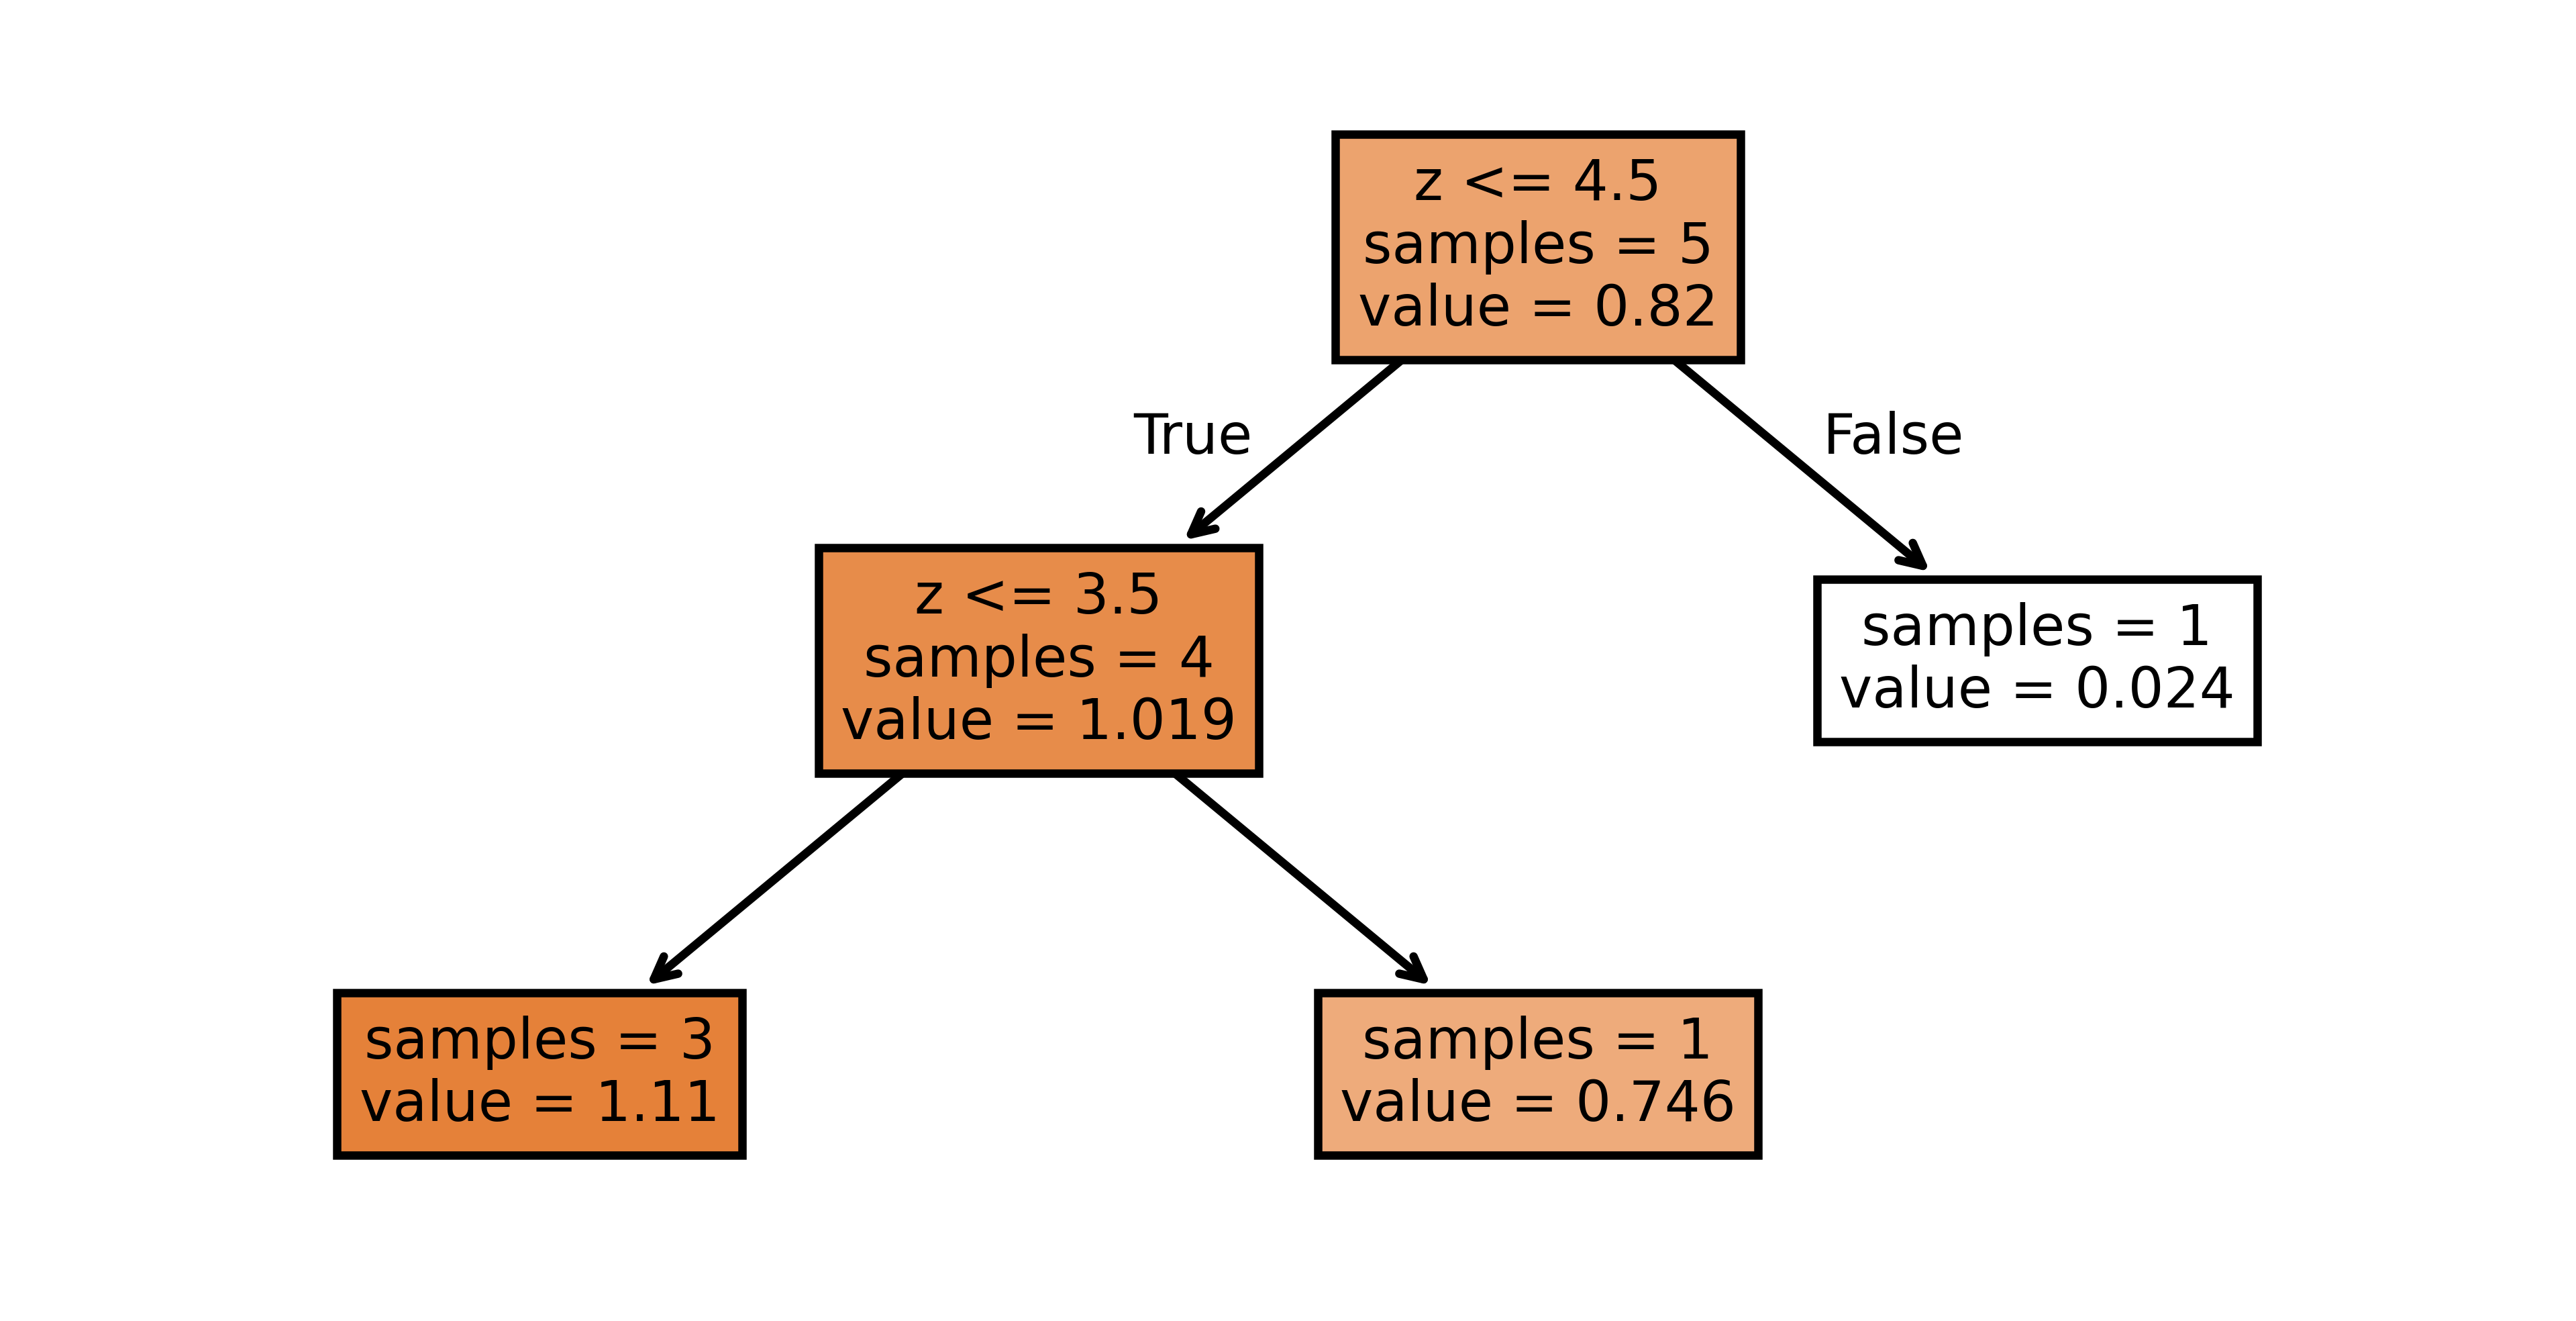

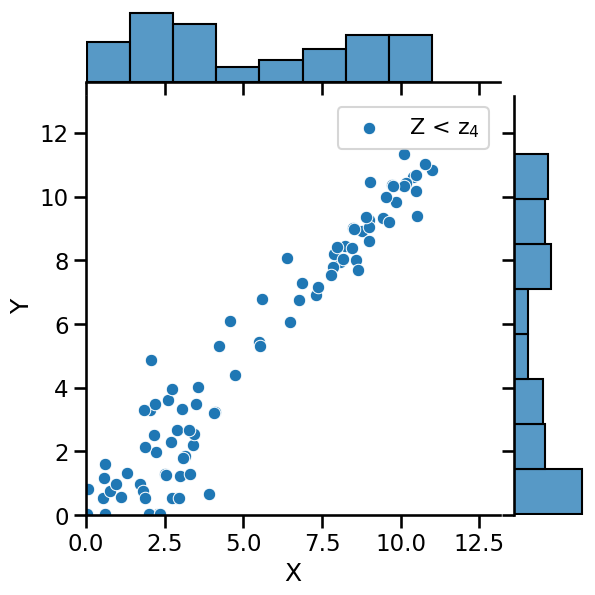

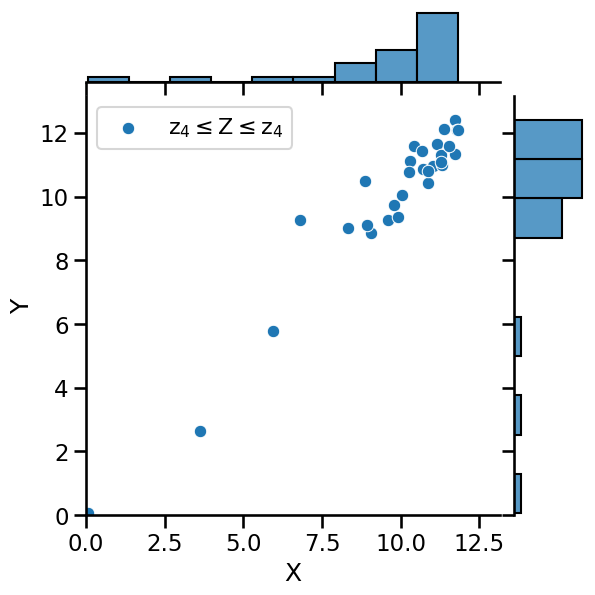

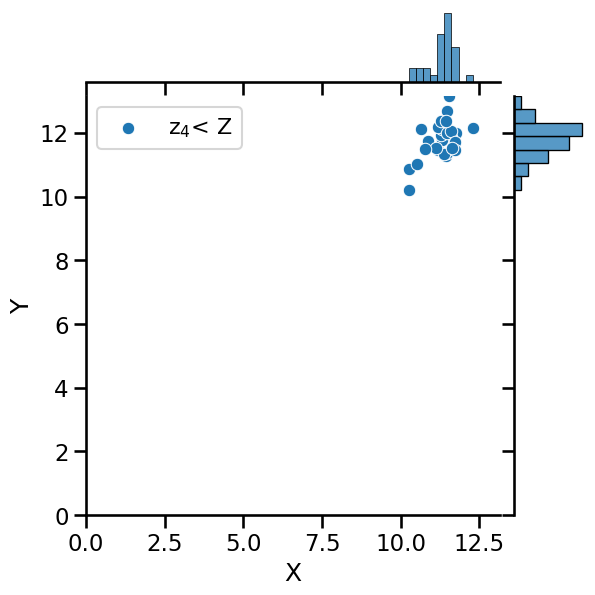

<Figure size 1200x600 with 0 Axes>

In [27]:
name_X = 'HOXA3'
name_Y = 'HOXA5'
name_Z = 'PBX3'
X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 1000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True)
I = [0,1,2]
visualisation_conditioned_val(timeseries, I, num, tlen, cond = [th1,th2])
print(np.sqrt(Sigma), np.sqrt(np.mean(Sigma_null_list)), P)

Sigma, T, Tn 0.27099232544524793 0.8243270502603108 0.4489859214859213
Sigma_mean_null 0.12851054577404505
T_mean_null 0.3559212069264936
Tn_mean_null 0.3029552627151951
P 0.001 P_T 0.001 P_Tn 0.134
Theta 3.096005961279887 Theta_T 3.5996437485909927 Theta_Tn 1.1737870234084238
2 5.3
4 7.2


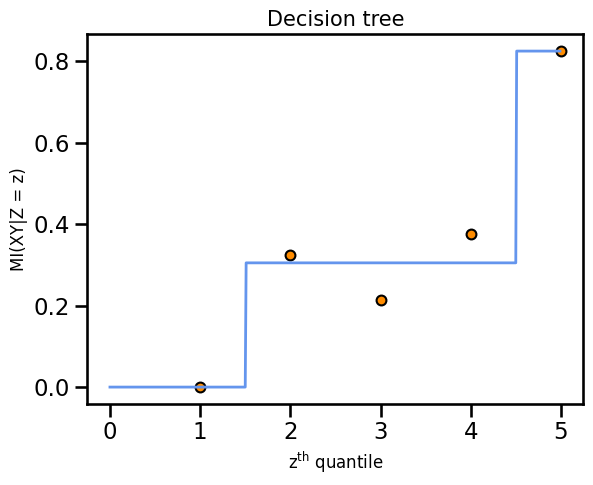

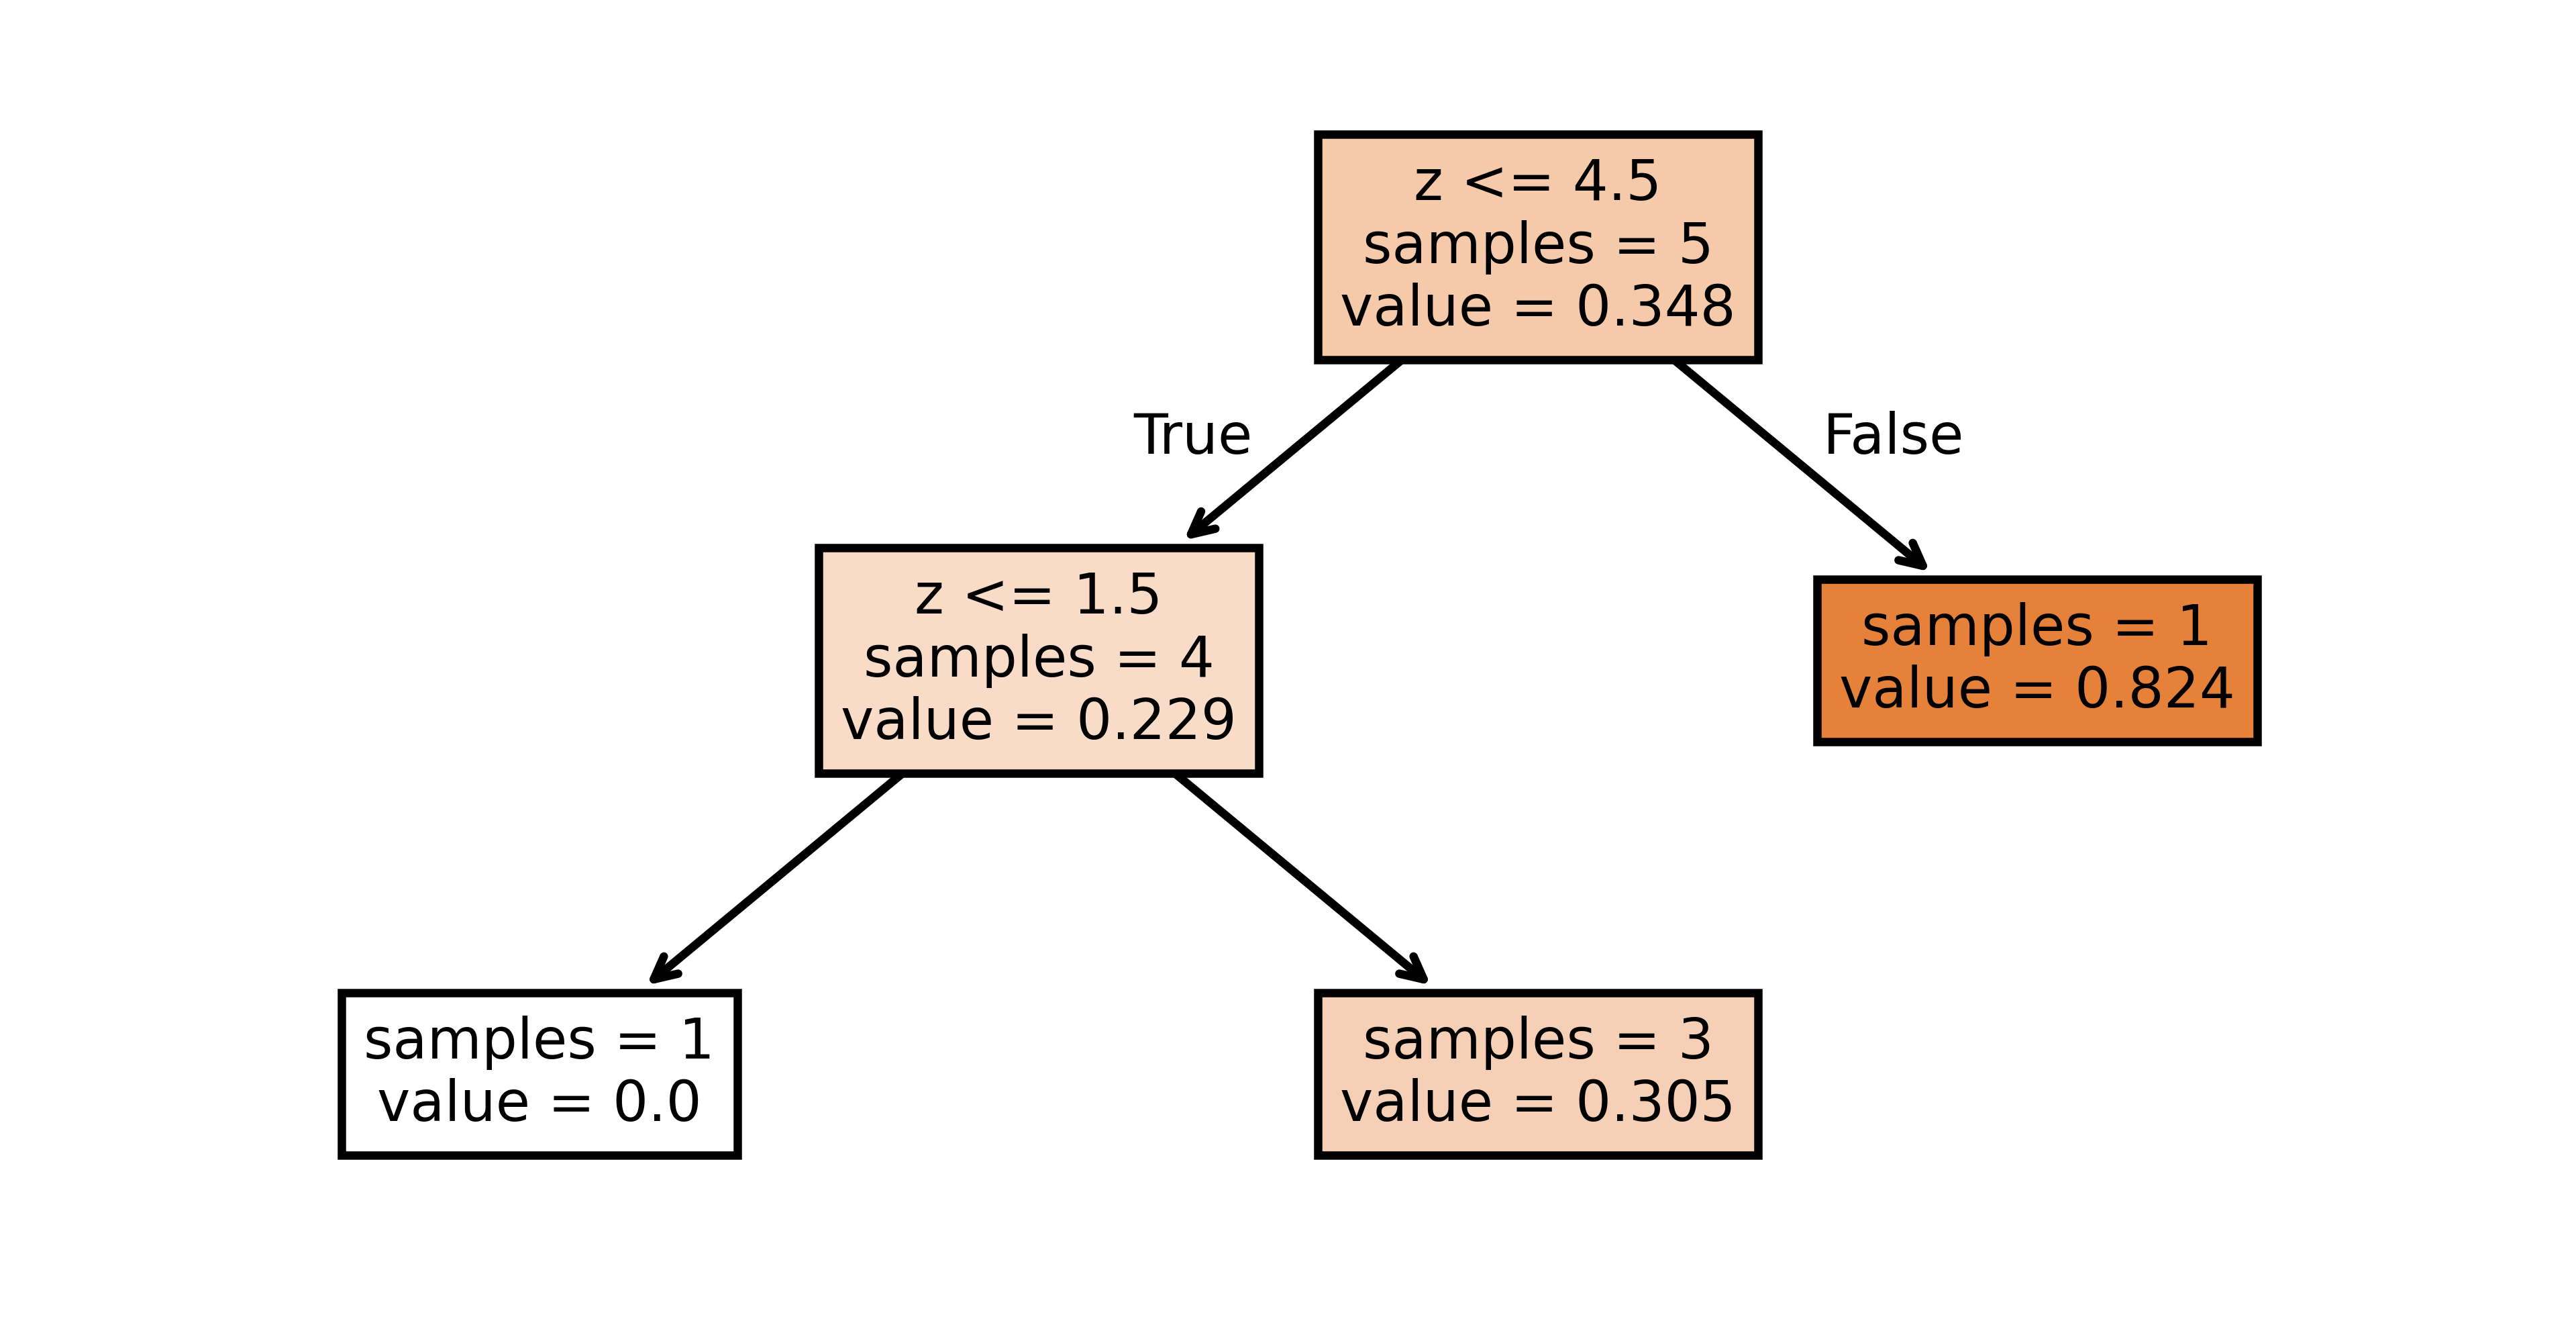

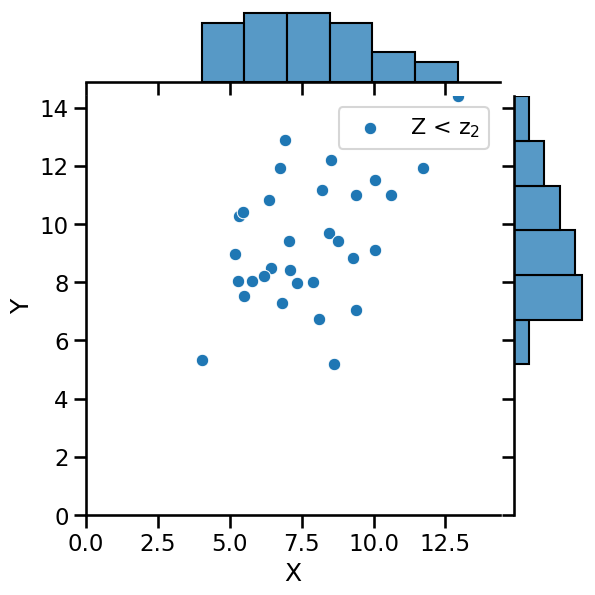

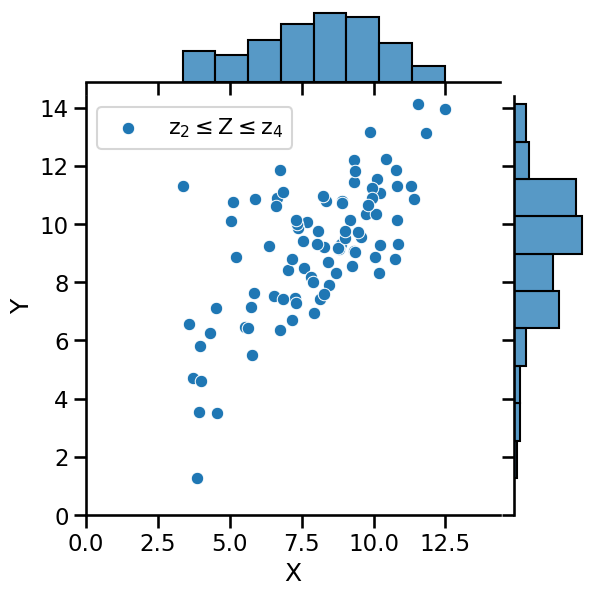

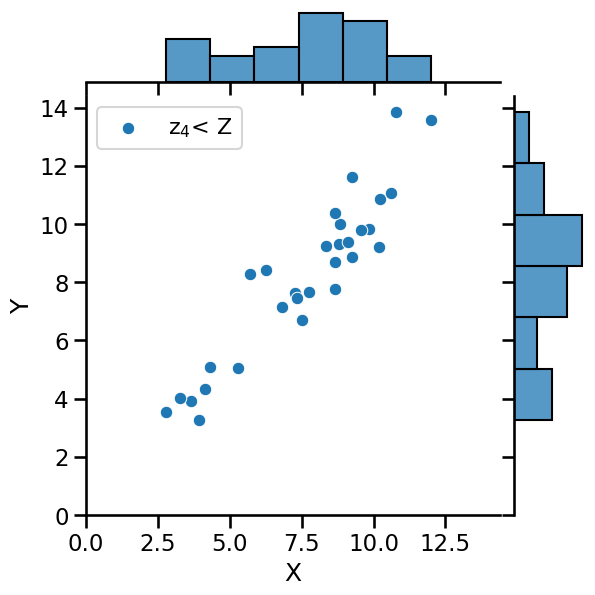

<Figure size 1200x600 with 0 Axes>

In [28]:
name_X = 'GATA1'
name_Y = 'TAL1'
name_Z = 'KLF5'
X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 1000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)
MI, MIz, MIC, Corr_Sigma, Sigma, T, Tn, MINDY, MI1, MI2 = ifc.mutual_information_analysis_continuous_extended(timeseries, [0,1,2], num, tlen)
x = range(1, num+1)
th1,th2,c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True, name=save_folder + '/' + 'good_decision_tree')
I = [0,1,2]
visualisation_conditioned_val(timeseries, I, num, tlen, name = save_folder + '/' + 'good', cond = [th1,th2])

### 3.3. Triadic non-monotonic  <a class="anchor" id="section_3_3"></a>

Sigma, T, Tn 0.19606190562166442 0.541483121313441 0.4690547573565813
Sigma_mean_null 0.10243781724374076
T_mean_null 0.2762871657171671
Tn_mean_null 0.23959102114207007
P 0.02 P_T 0.014 P_Tn 0.022
Theta 2.3548735553477647 Theta_T 2.4736561961703747 Theta_Tn 2.2815400246903126
0.44278878217685735 0.32005908398878596 0.02


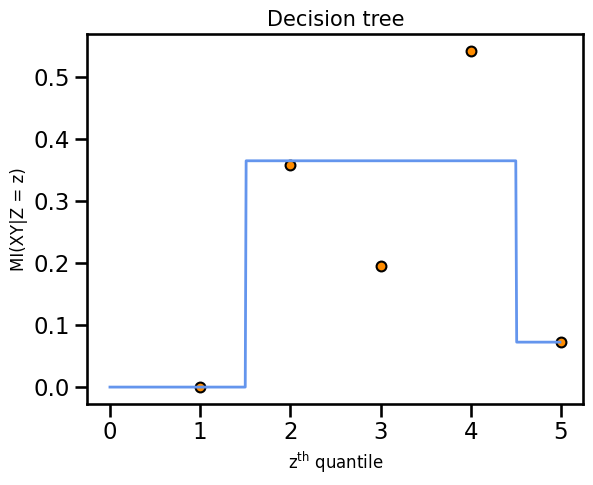

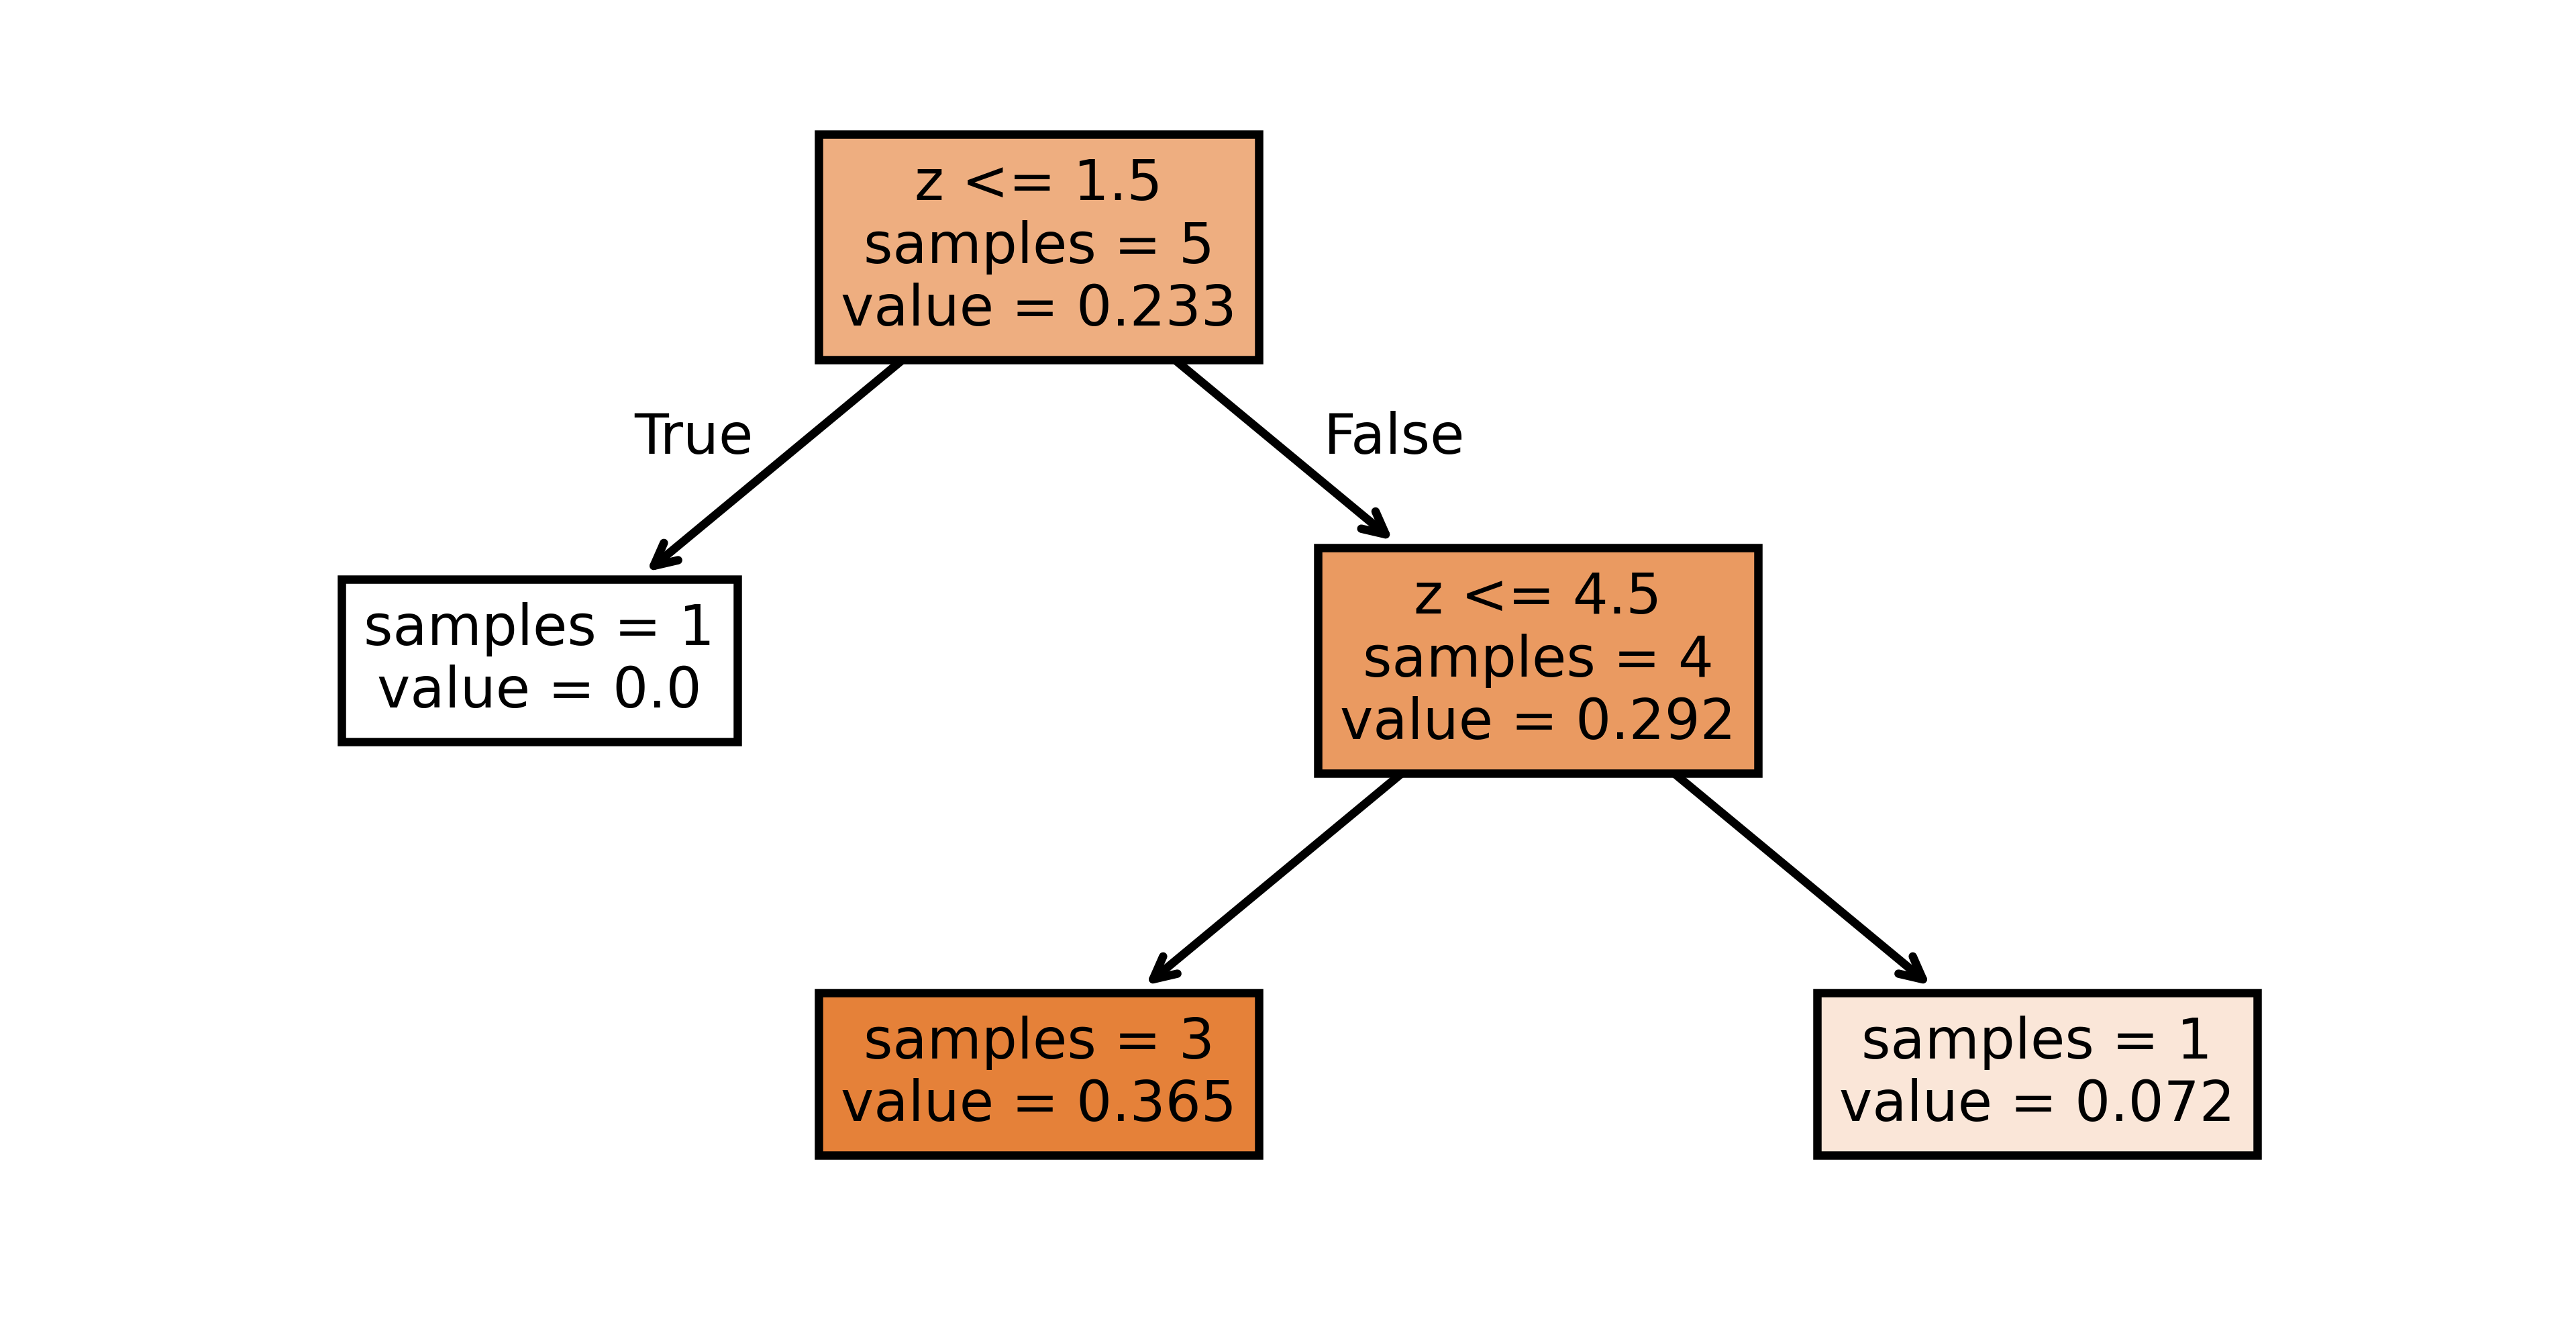

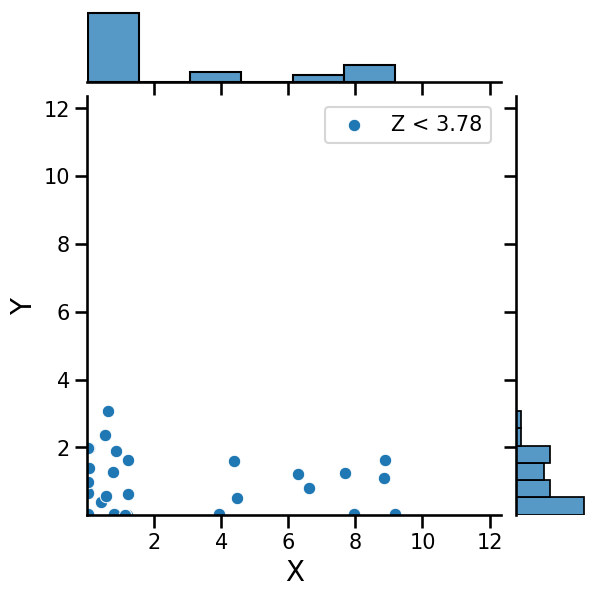

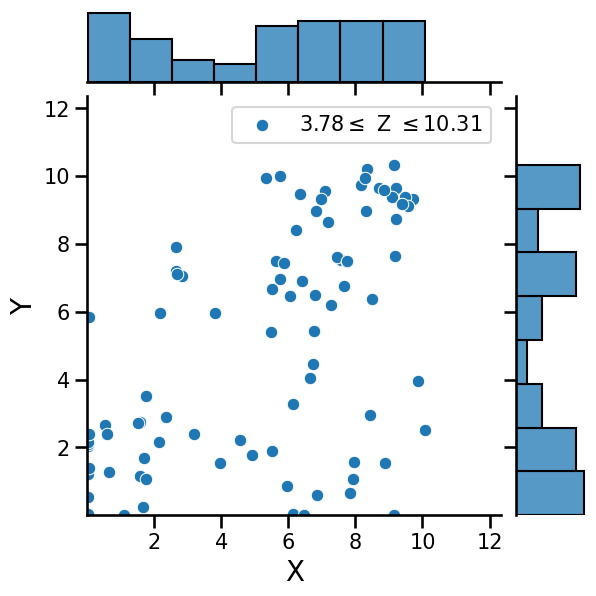

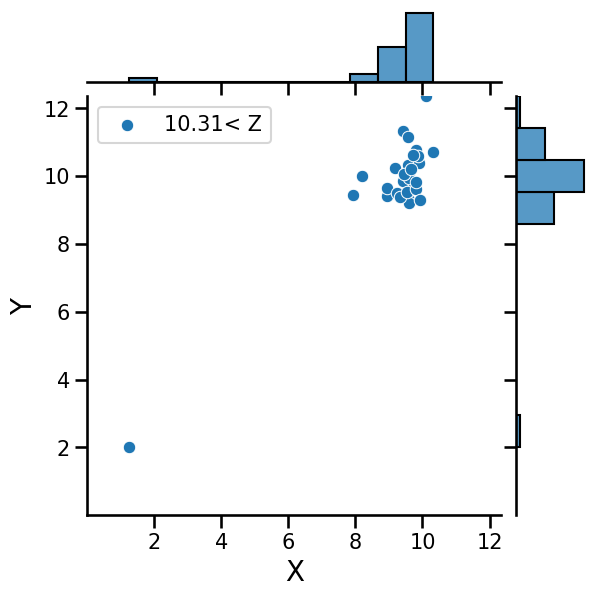

<Figure size 1200x600 with 0 Axes>

In [29]:
name_X = 'HOXA7'
name_Y = 'HOXB5'
name_Z = 'HOXB2'
X = np.array(gene_expression.T[name_X])
Y = np.array(gene_expression.T[name_Y])
Z = np.array(gene_expression.T[name_Z])
timeseries = np.zeros((3,len(X)))
timeseries[0,:] = X
timeseries[1,:] = Y
timeseries[2,:] = Z
I = [1,2,3]
num = 5
tlen = len(X)
nrunmax = 1000
MI, MIz, MIz_null, MIC, Theta_S, Theta2_T, Theta2_Tn, Sigma, Sigma_null_list, P, P_T, P_Tn = ifc.Theta_score_null_model(timeseries, I, num, tlen, nrunmax, True, True)

x = range(1, num+1)
th1, th2, c = decision_tree(x, MIz, disp_fig=True, disp_txt_rep=True,
              disp_tree=True, name=None)
I = [0,1,2]
visualisation_conditioned(timeseries, I, num, tlen, cond = [th1,th2])

print(np.sqrt(Sigma), np.sqrt(np.mean(Sigma_null_list)), P)

## 4. Distribution for an edge  <a class="anchor" id="section_4"></a> 

### HOXB5-HOXB6

In [30]:
edge_short_range_data = sorted(glob.glob('../data/HOXB5_HOXB6/*'))

In [31]:
edge_short_range_data

['../data/HOXB5_HOXB6/test_0.tsv',
 '../data/HOXB5_HOXB6/test_1.tsv',
 '../data/HOXB5_HOXB6/test_2.tsv',
 '../data/HOXB5_HOXB6/test_3.tsv',
 '../data/HOXB5_HOXB6/test_4.tsv',
 '../data/HOXB5_HOXB6/test_5.tsv',
 '../data/HOXB5_HOXB6/test_6.tsv',
 '../data/HOXB5_HOXB6/test_7.tsv']

In [32]:
temp_edge_short_range_list = list()
for k in edge_short_range_data:
    temp2 = pd.read_csv(k, sep = '\t', index_col = 0, header = None)
    temp_edge_short_range_list.append(temp2)

final_temp_edge_short_range = pd.concat([temp_edge_short_range_list[i] for i in range(len(temp_edge_short_range_list))],axis=1)
temp_edge_short_range = final_temp_edge_short_range.T.reset_index(drop = True)
temp_edge_short_range['P'] = temp_edge_short_range['P'].astype(float)

In [33]:
temp_edge_short_range

,reg,node1,node2,MI,MIC,Theta,Theta_T,Theta_Tn,Sigma,Sigma_null,T,T_null,Tn,Tn_null,P,P_T,P_Tn
0,AHR,HOXB5,HOXB6,1.1664079793536422,0.9584375851502577,0.6661993934320491,0.5827848443674346,0.45560248732210207,0.09311180050254138,0.12221446242469401,0.26531783031783096,0.3378597788481965,0.23324111074111054,0.2865972837048622,0.7356,0.7068,0.6412
1,ALX1,HOXB5,HOXB6,1.1664079793536422,1.0210699555032163,1.032944210748584,1.2161399138298374,0.8823059882698456,0.1701314944641895,0.12405203104674334,0.495123025123025,0.3426217073763447,0.39698773448773506,0.2908315483250242,0.1584,0.1168,0.1874
2,ALX3,HOXB5,HOXB6,1.1664079793536422,0.9849675024007631,0.5540158331235402,0.794021031871713,1.2369739676560756,0.1484052333025038,0.12420482596271525,0.44219456469456464,0.3438361581247619,0.44219456469456464,0.2930684627686717,0.2826,0.2044,0.1114
3,ALX4,HOXB5,HOXB6,1.1664079793536422,0.986488398171659,0.07751729958106812,0.22986434579286102,0.2040441646879953,0.11963283477935616,0.12297458670942488,0.3117100954600962,0.33974098545274994,0.3117100954600962,0.2878735760332407,0.5100,0.5666,0.384
4,AR,HOXB5,HOXB6,1.1664079793536422,0.8874053581180306,0.5425357768109049,0.7022117927440308,0.46395511721935484,0.14628292785479458,0.12276241220548971,0.4250012025012022,0.339072049052184,0.23482961482961495,0.2892352558224046,0.2842,0.2352,0.6426
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
634,SPIC,HOXB5,HOXB6,1.1664079793536422,0.8583307687640296,0.4342050912474996,0.6179001984049958,1.0650886661474719,0.1422563035660274,0.12327346312539435,0.41753848003848004,0.3411634390460151,0.41753848003848004,0.28984681311620863,0.3240,0.2636,0.1466
635,TFAP2A,HOXB5,HOXB6,1.1664079793536422,1.0060912860245468,0.29541548639135345,0.3357314306780716,0.1423608304269842,0.11068686771888309,0.1236923434391666,0.300189625189625,0.34189914558341905,0.27476273726273726,0.291818001033974,0.5874,0.5996,0.5148
636,ZBTB1,HOXB5,HOXB6,1.1664079793536422,0.9720999135625863,0.6532749017273656,0.5413816439704527,0.48563453362824577,0.09408383386193778,0.12320636578232712,0.2727096052096054,0.34091275913756364,0.23106615606615666,0.28965649072518795,0.7266,0.6814,0.6552
637,ZBTB7C,HOXB5,HOXB6,1.1664079793536422,1.0835223364555973,0.7276117552074138,0.6630525332982625,0.46020560604253447,0.09026445683076728,0.12226358555159227,0.25611268361268347,0.33897619791878103,0.23313529063529037,0.2882983913798894,0.7538,0.7304,0.6442


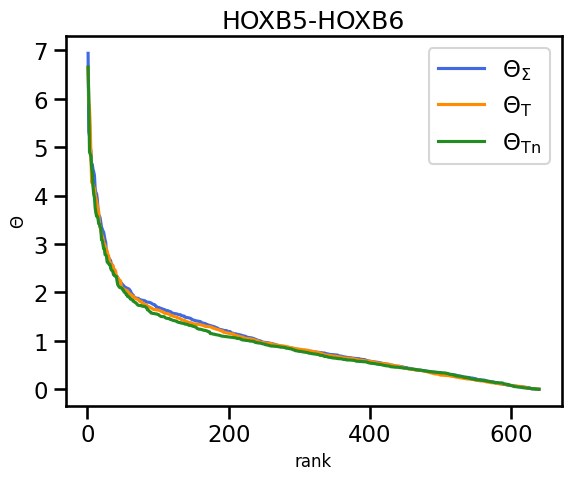

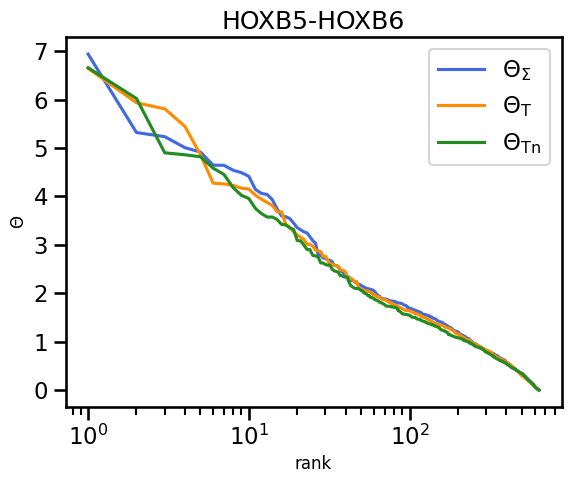

In [34]:
name = 'HOXB5-HOXB6'
temp_edge_short_range[['Theta', 'Theta_T', 'Theta_Tn']] = temp_edge_short_range[['Theta', 'Theta_T', 'Theta_Tn']].astype(float)
X1 = temp_edge_short_range.sort_values(by = 'Theta', ascending = False)['Theta'].values
X2 = temp_edge_short_range.sort_values(by = 'Theta_T', ascending = False)['Theta_T'].values
X3 = temp_edge_short_range.sort_values(by = 'Theta_Tn', ascending = False)['Theta_Tn'].values

density = sp.stats.gaussian_kde(X1)
n, x, _ = plt.hist(X1, bins = np.linspace(0, np.max(X1), 50), histtype=u'step', density=True)  
plt.plot(x, density(x), label = r'$\mathregular{\Theta_\Sigma}$', color = 'royalblue')

density = sp.stats.gaussian_kde(X2)
n, x, _ = plt.hist(X2, bins = np.linspace(0, np.max(X2), 50), histtype=u'step', density=True)  
plt.plot(x, density(x), label = r'$\mathregular{\Theta_T}$', color = 'darkorange')

density = sp.stats.gaussian_kde(X3)
n, x, _ = plt.hist(X3, bins = np.linspace(0, np.max(X3), 50), histtype=u'step', density=True)  
plt.plot(x, density(x), label = r'$\mathregular{\Theta_{Tn}}$', color = 'forestgreen')

plt.xlabel(r'$\mathregular{\Theta}$', fontsize=12)
plt.ylabel('Probability density function', fontsize=12)
plt.title(name)
plt.legend()
plt.savefig(save_folder + '/' + 'edge_score1.png', format = 'png', dpi = 600)
plt.close()

plt.plot(np.arange(1,len(X1)+1), X1, label = r'$\mathregular{\Theta_\Sigma}$', color = 'royalblue')
plt.plot(np.arange(1,len(X2)+1), X2, label = r'$\mathregular{\Theta_T}$', color = 'darkorange')  
plt.plot(np.arange(1,len(X3)+1), X3, label = r'$\mathregular{\Theta_{Tn}}$', color = 'forestgreen') 
plt.xlabel('rank', fontsize=12)
plt.ylabel(r'$\mathregular{\Theta}$', fontsize=12)
plt.title(name)
plt.legend()
plt.savefig(save_folder + '/' + 'edge_score2.png', format = 'png', dpi = 600)
plt.show()

plt.plot(np.arange(1,len(X1)+1), X1, label = r'$\mathregular{\Theta_\Sigma}$', color = 'royalblue')
plt.plot(np.arange(1,len(X2)+1), X2, label = r'$\mathregular{\Theta_T}$', color = 'darkorange')  
plt.plot(np.arange(1,len(X3)+1), X3, label = r'$\mathregular{\Theta_{Tn}}$', color = 'forestgreen') 
plt.xscale('log')
#plt.yscale('log')
plt.xlabel('rank', fontsize=12)
plt.ylabel(r'$\mathregular{\Theta}$', fontsize=12)
plt.title(name)
plt.legend()
plt.savefig(save_folder + '/' + 'edge_score3.png', format = 'png', dpi = 600)
plt.show()


## 5. Visualisation of triadic network  <a class="anchor" id="section_5"></a> 

In [35]:
# from trim.triadic_vis import triadic_network_vis_from_data_and_graph

# sub_triadic = pd.concat([short_range[short_range['P']<0.001], long_range[long_range['P']<0.001]]).reset_index()
# sub_sub_triadic = sub_triadic.sort_values(by='Theta', ascending=False).reset_index()
# sub_sub_triadic = sub_sub_triadic[0:10]

# set_nodes = set(sub_sub_triadic['reg']).union(set(sub_sub_triadic['node1'])).union(set(sub_sub_triadic['node2']))
# graph_ppi.remove_edges_from(list(nx.selfloop_edges(graph_ppi)))
# sub_graph = nx.Graph(graph_ppi.subgraph(list(set_nodes)))

# sub_final = sub_triadic[sub_triadic['node1'].isin(set_nodes)]
# sub_final = sub_final[sub_final['node2'].isin(set_nodes)]
# sub_final = sub_final[sub_final['reg'].isin(set_nodes)]
# sub_final = sub_final.reset_index(drop=True)
# top = len(sub_final)

In [36]:
# Corr_Sigma_list = list()
# for k in range(len(sub_final)):
#     name_X = sub_final['node1'].iloc[k]
#     name_Y = sub_final['node2'].iloc[k]
#     name_Z = sub_final['reg'].iloc[k]
#     X = np.array(gene_expression.T[name_X])
#     Y = np.array(gene_expression.T[name_Y])
#     Z = np.array(gene_expression.T[name_Z])
#     timeseries = np.zeros((3,len(X)))
#     timeseries[0,:] = X
#     timeseries[1,:] = Y
#     timeseries[2,:] = Z
#     num = 5
#     tlen = len(X)
#     I = [0,1,2]
#     MI, MIz, MIC, Corr_Sigma, Sigma, T, Tn, MINDY, MI1, MI2 = ifc.mutual_information_analysis_continuous_extended(timeseries, I, num, tlen)
#     Corr_Sigma_list.append(Corr_Sigma)

# sub_final['corr'] = pd.Series(Corr_Sigma_list).astype(float)

In [37]:
# triadic_network_vis_from_data_and_graph(sub_graph, sub_final, top)